In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [2]:
df = pd.read_csv(r'/media/tien/GeneralData/MachineLearning /Dataset/medical-charges.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
px.scatter(df,x='age',y='charges',color='smoker',opacity=0.5,trendline='ols',height=800)


In [4]:
Q1=df['charges'].quantile(0.25)
Q3=df['charges'].quantile(0.75)
IQR=Q3-Q1
Q1_out=Q1-1.5*IQR
Q3_out=Q3+1.5*IQR
target=df['charges']

In [5]:
clean_data=df.loc[(target<=Q3+1.5*IQR) & (target>=Q1-1.5*IQR)]
clean_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
px.scatter(clean_data,x='age',y='charges',color='smoker',opacity=0.5,trendline='ols',height=800)

In [7]:
df['sex']=df['sex'].apply(lambda x: 1 if x=='male' else 0)
df['smoker']=df['smoker'].apply(lambda x: 1 if x=='yes' else 0)
clean_data['sex']=clean_data['sex'].apply(lambda    x: 1 if x=='male' else 0)
clean_data['smoker']=clean_data['smoker'].apply(lambda x: 1 if x=='yes' else 0)

/tmp/ipykernel_5689/3179892929.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_5689/3179892929.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [8]:
model_raw=LinearRegression()
model_lean=LinearRegression()
model_raw.fit(df.iloc[:,:-2],df['charges'])
model_lean.fit(clean_data.iloc[:,:-2],clean_data['charges'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
model_raw.coef_

array([  257.73498767,  -128.63985357,   322.36421449,   474.41112061,
       23823.39253065])

In [10]:
model_lean.coef_

array([  243.35819716,  -356.27233991,    51.20850242,   408.80974241,
       14643.46646185])

In [11]:
model_raw.intercept_

np.float64(-12052.461985664733)

In [12]:
model_lean.intercept_

np.float64(-3056.1386401987857)

In [13]:
def rmse(y_true,y_pred):
    return np.sqrt(np.mean((y_true-y_pred)**2))


In [14]:
rmse(df['charges'],model_raw.predict(df.iloc[:,:-2]))

np.float64(6056.100708754546)

In [15]:
rmse(clean_data['charges'],model_lean.predict(clean_data.iloc[:,:-2]))

np.float64(4582.10162366535)

In [16]:
clean_data.sample(5)

,age,sex,bmi,children,smoker,region,charges
458,56,1,39.60,0,0,southwest,10601.41200
983,27,0,30.59,1,0,northeast,16796.41194
487,19,1,28.70,0,0,southwest,1253.93600
662,32,0,31.54,1,0,northeast,5148.55260
57,18,1,31.68,2,1,southeast,34303.16720


In [17]:
model_raw.predict([[19,0,25.6,0,0]])

/home/tien/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([1097.02667089])

In [18]:
model_lean.predict([[19,0,25.6,0,0]])

/home/tien/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([2878.60476769])

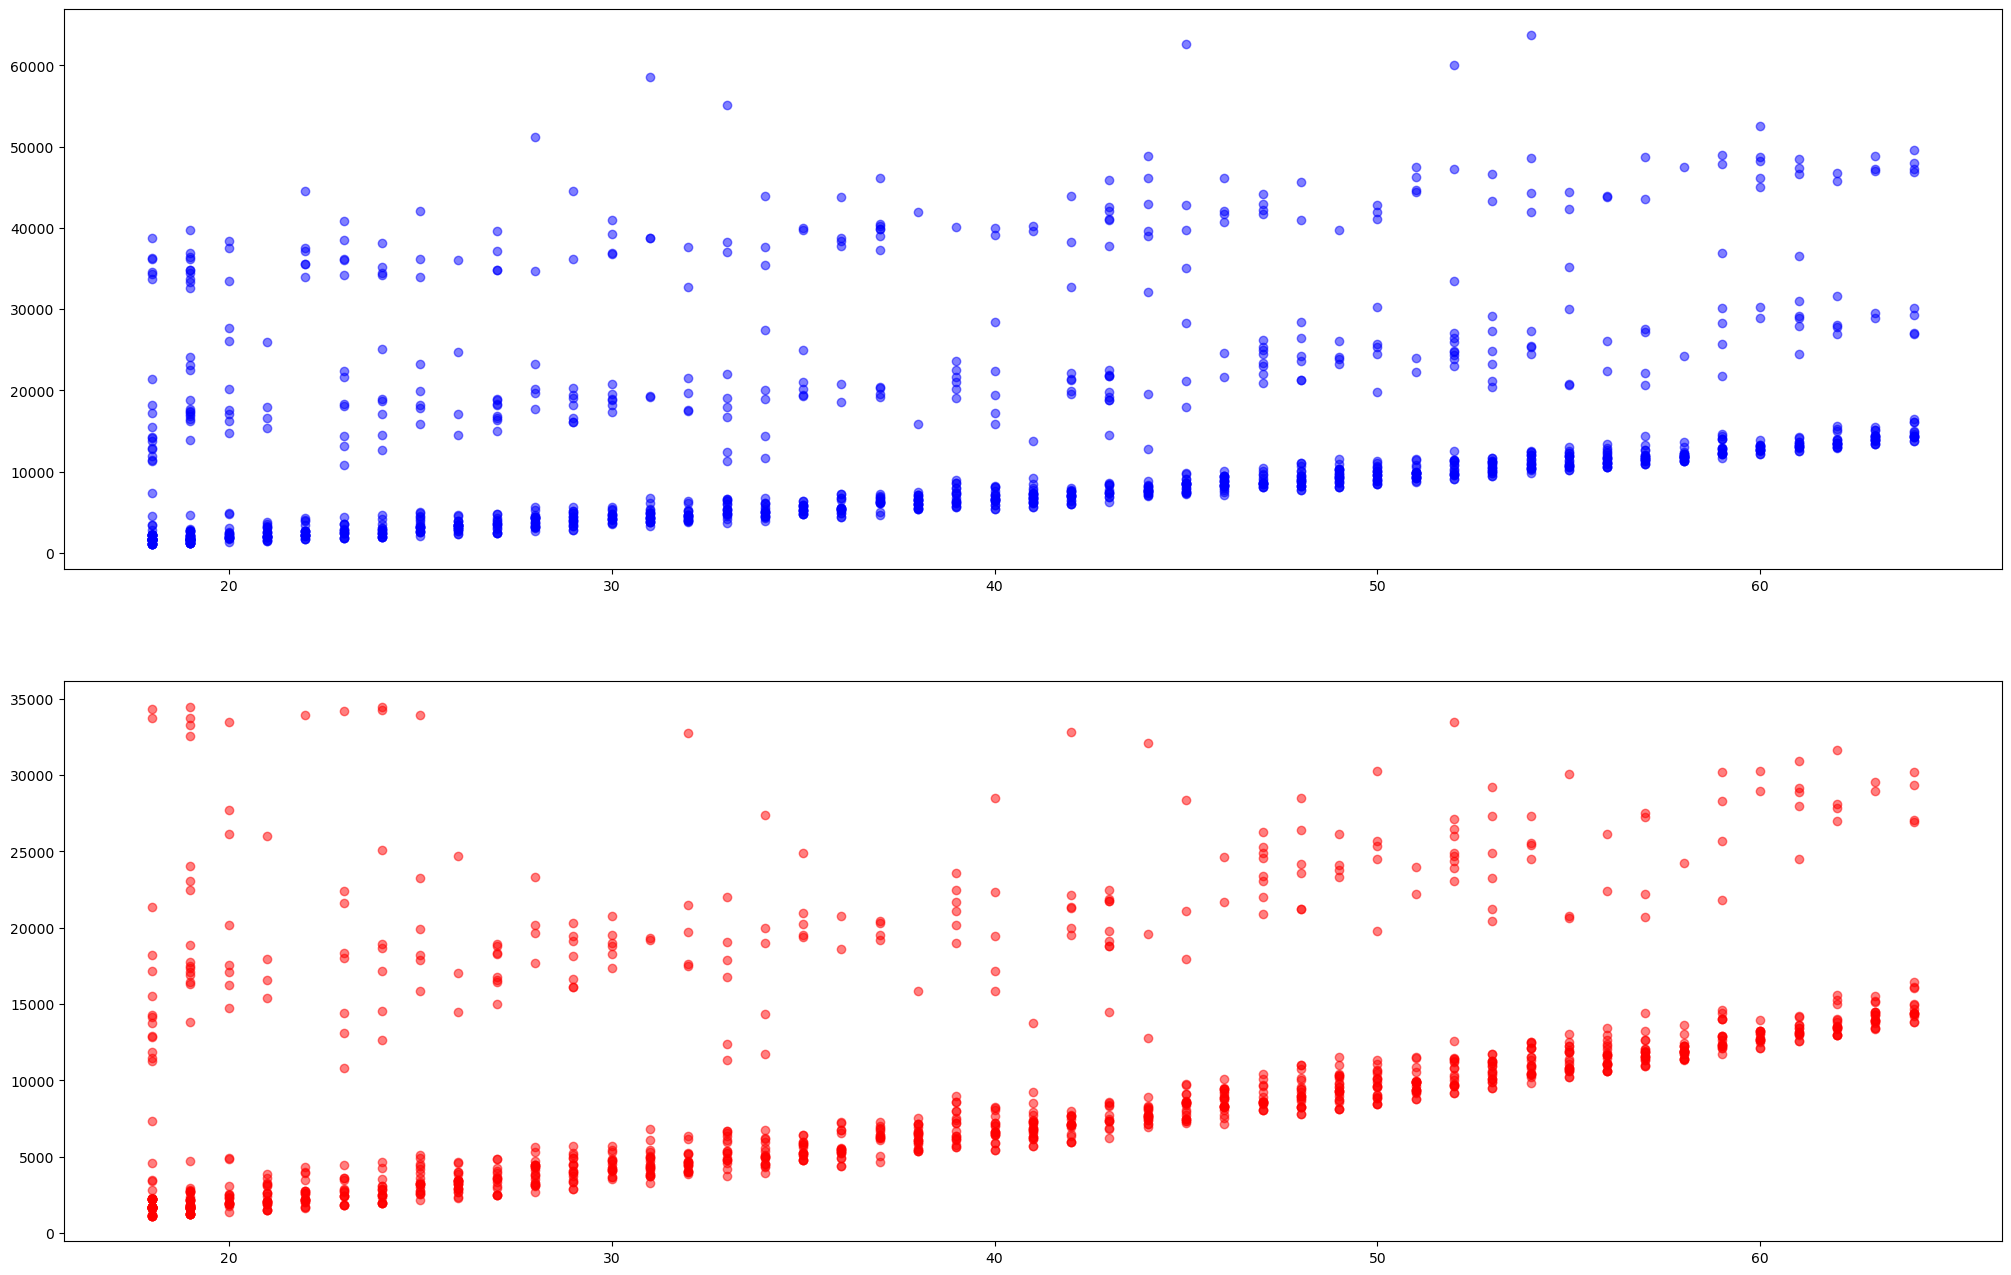

In [19]:

fig,(row1,row2)=plt.subplots(nrows=2)
fig.figure.set_size_inches(25,16)
row1.scatter(df['age'],df['charges'],color='blue',alpha=0.5)
row2.scatter(clean_data['age'],clean_data['charges'],color='red',alpha=0.5)


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X=df.iloc[:,:-2]
y=df['charges']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Chỉ học (fit) trên tập Train để tránh rò rỉ dữ liệu (Leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Chỉ dùng kết quả đã học để biến đổi (transform) tập Validation
X_val_scaled = scaler.transform(X_val)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


In [24]:
X_train_scaled

array([[-0.01469359, -1.01506361,  0.36618845, -0.89412402, -0.50932723],
       [ 1.40627649,  0.98515994,  1.06914341, -0.06347177, -0.50932723],
       [-0.44098461,  0.98515994,  0.76589191, -0.89412402, -0.50932723],
       ...,
       [ 1.33522798,  0.98515994, -0.88033051, -0.89412402, -0.50932723],
       [-0.15679059, -1.01506361,  2.78566134,  0.76718049,  1.96337432],
       [ 1.12208247,  0.98515994, -0.10789745, -0.89412402, -0.50932723]],
      shape=(1204, 5))

In [25]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
rmse(y_val,prediction)

np.float64(5727.3855583749655)

In [28]:
scaler.var_

array([1.98102578e+02, 2.49944123e-01, 3.74181157e+01, 1.44931071e+00,
       1.63552279e-01])

In [29]:
scaler.mean_

array([39.20681063,  0.50747508, 30.56001246,  1.07641196,  0.20598007])

In [30]:
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [31]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [47]:
my_detail=[[19,1,25.6,0]]

In [33]:
df_non_smoke=df.loc[df['smoker']==0,['age','sex','bmi','children','charges']]
df_smoke=df.loc[df['smoker']==1,['age','sex','bmi','children','charges']]
X=['age','sex','bmi','children']
Y='charges'

In [41]:
model_smoke=LinearRegression().fit(df_smoke[X],df_smoke[Y])
model_non_smoke=LinearRegression().fit(df_non_smoke[X],df_non_smoke[Y])
model=LinearRegression().fit(df[['age','sex','bmi','children','smoker']],df[Y])

In [51]:
model_smoke.predict(my_detail)

/home/tien/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([19123.78441545])

In [48]:
model_non_smoke.predict(my_detail)

/home/tien/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([2106.78529937])

In [45]:
model.predict([[19,1,25.6,0,0]])

/home/tien/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([968.38681732])

In [49]:
model.predict([[19,1,25.6,0,1]])


/home/tien/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([24791.77934798])